In [1]:
import sys
import os
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

In [ ]:
import Scores_Evaluation.ScoresEvaluator_2 as SE
from InputFileType import InputFileType
from utils_for_structures_and_fasta import extract_uids_from_fasta, download_fasta_record, uniprot_accessions_to_uniparc_accessions, copy_records_from_fasta, filter_input_file, uniprot_accessions_to_uniparc_accessions

In [3]:
# test-seeds for generated datasets: ["P68871", "Q99895", "P42212", "P00734", "P69905", "P0A6F5"]
PATH_TO_RECOVERED_CLANS = "/home/aronw/Development/clans-recovered" # path to old recovered clans project
CLUSTER_ROUNDS = 100000 # sets the number of rounds for clustering in recovered clans
EXAMPLE_GENERATED_DATA_SETS = {"dataset1": {"size_of_dataset": 30, "number_of_clusters": 1, "seeds": ["P68871"]}}
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/datasets_for_evaluation/datasets_tsv"

In [4]:
upi = uniprot_accessions_to_uniparc_accessions(["A0A427FID0"])
print(upi)
record = download_fasta_record("A0A427FID0", upi="UPI000F79D2DA")
print(record)

{'A0A427FID0': 'UPI000F79D2DA'}
ID: UPI000F79D2DA
Name: UPI000F79D2DA
Description: UPI000F79D2DA status=active
Number of features: 0
Seq('MLTSFSLSELILISAGYLLVLFGVAWVSEHGLIPRWIIRHPLTYTLSLGVYASA...VAM')


In [5]:
test_dataset = "/home/aronw/Development/Clans-3D/example_files/small_fasta_files/50.fasta"
#test_dataset_filterd = filter_input_file(test_dataset, test_dataset.replace(".fasta", "_filtered.fasta"), InputFileType.FASTA)

In [8]:
evaluator = SE.ScoresEvaluator(PATH_TO_RECOVERED_CLANS)
structural_vs_sequence_dict = evaluator.initialize_evaluation(
        rounds_to_cluster=CLUSTER_ROUNDS,
        datasets_meta_data=None,
        use_existing_datasets=True,
        path_to_dir_of_existing_datasets=EXAMPLE_DATASET_TSV,
        datasets_file_type=InputFileType.TSV
    )

Initializing evaluation...
Downloaded 30 from 30 PDB files successfully.
Computing scores for dataset test_1...
Computing structural similarity with foldseek...
Structural similarity computation with foldseek completed.
Generating CLANS file in /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim...


KeyError: 'A0A6I7NAB6'

Evaluating structural clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/50_cleaned_out.clans with sequence clans file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/50_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_structsim/50_cleaned_out.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/clans_files_seqsim/50_cleaned_out.clans...
     PDBchain1  PDBchain2  score_struct     score_seq  score_struct_log10  \
0            9         27  2.437000e-11  9.920000e-51           10.613144   
1            9         26  1.904000e-11  1.510000e-49           10.720333   
2            9         25  6.342000e-11  2.520000e-50           10.197774   
3            9         24  2.538000e-11  1.510000e-49           10.595508   
4            9         29  3.262000e-11  1.510000e-49           10.486516   
..         ...        ...           ...           ...          

TypeError: ScoresEvaluator._build_graph_from_scores() takes 2 positional arguments but 3 were given

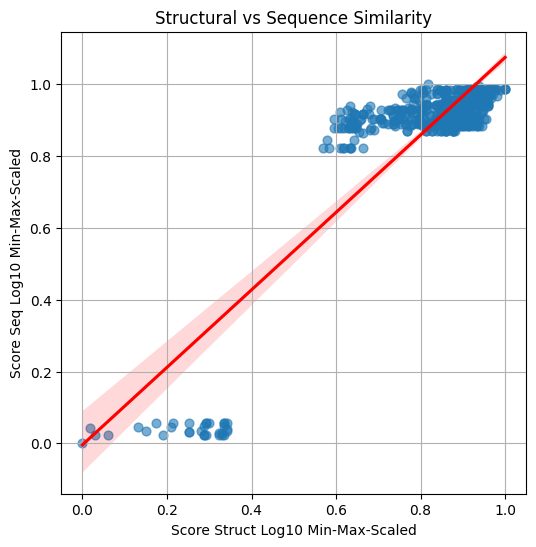

In [7]:
evaluation_results_df = evaluator.evaluate(structural_vs_sequence_dict)